In [1]:
import boto3
import sagemaker
import pandas as pd
import numpy as np
from sagemaker import get_execution_role
from sagemaker.inputs import TrainingInput

role = get_execution_role()
session = sagemaker.Session()
region = session.boto_region_name

# Update this to your actual bucket name
bucket = "spy-volatility-forecast-yusuf"
prefix = "volatility-forecast"

print(f"Region: {region}")
print(f"Role: {role}")
print(f"Bucket: {bucket}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Region: us-east-2
Role: arn:aws:iam::074412166434:role/service-role/AmazonSageMaker-ExecutionRole-20260304T105542
Bucket: spy-volatility-forecast-yusuf


In [3]:
train_df = pd.read_csv(f"s3://{bucket}/{prefix}/data/train/10YSPYTRAIN.csv")
val_df = pd.read_csv(f"s3://{bucket}/{prefix}/data/validation/10YSPYVALIDATION.csv")
test_df = pd.read_csv(f"s3://{bucket}/{prefix}/data/test/10YSPYTEST.csv")

print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")
print(f"\nTarget distribution (train):")
print(train_df.iloc[:, 0].describe())

Train: (1996, 18)
Validation: (124, 18)
Test: (411, 18)

Columns: ['TARGET_NEXT_DAY_RANGE_PCT', 'DAILY_RETURN_PCT', 'OVERNIGHT_GAP_PCT', 'INTRADAY_RANGE_PCT', 'CLOSE_LOCATION_IN_RANGE', 'HIGH_VS_PREV_CLOSE_PCT', 'LOW_VS_PREV_CLOSE_PCT', 'AVG_RANGE_5D', 'AVG_RANGE_10D', 'AVG_RANGE_20D', 'STDDEV_RETURN_5D', 'STDDEV_RETURN_20D', 'VOLUME_RATIO_20D', 'RETURN_5D', 'RETURN_20D', 'DOWN_DAYS_LAST_3', 'DAY_OF_WEEK', 'MONTH_OF_YEAR']

Target distribution (train):
count    1996.000000
mean        1.153484
std         0.910354
min         0.122907
25%         0.574880
50%         0.886667
75%         1.413918
max         8.522093
Name: TARGET_NEXT_DAY_RANGE_PCT, dtype: float64


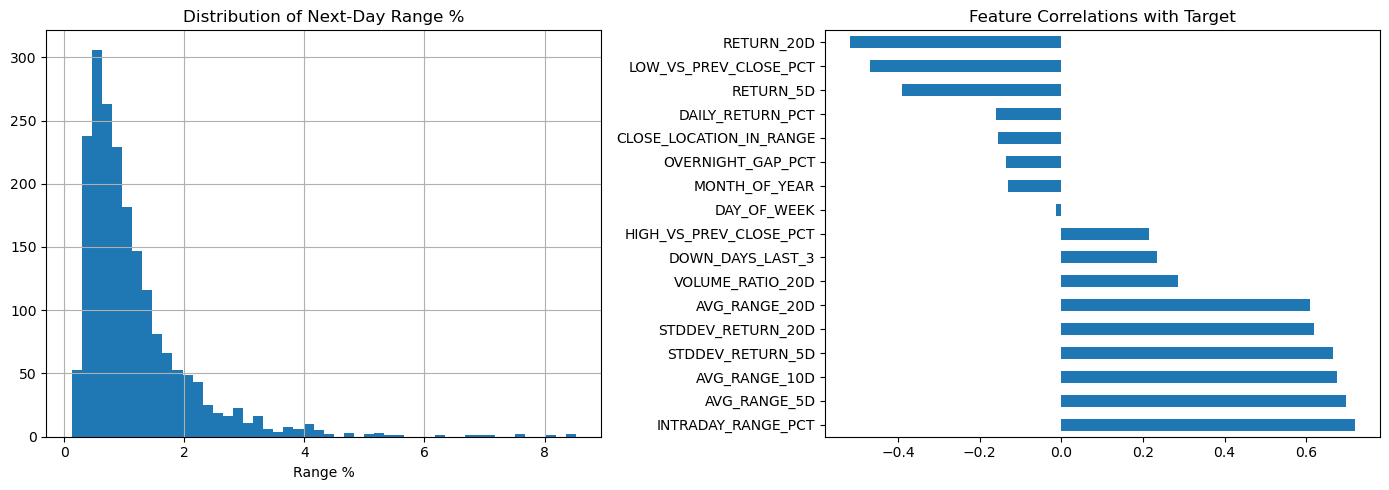

In [4]:
import matplotlib.pyplot as plt

target = train_df.iloc[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target.hist(bins=50, ax=axes[0])
axes[0].set_title("Distribution of Next-Day Range %")
axes[0].set_xlabel("Range %")

corrs = train_df.corr().iloc[:, 0].drop(train_df.columns[0]).sort_values(ascending=False)
corrs.plot(kind="barh", ax=axes[1])
axes[1].set_title("Feature Correlations with Target")
plt.tight_layout()
plt.show()

In [5]:
# Save headerless CSVs back to S3
train_df.to_csv(f"s3://{bucket}/{prefix}/data/train/train_xgb.csv",
                index=False, header=False)
val_df.to_csv(f"s3://{bucket}/{prefix}/data/validation/val_xgb.csv",
              index=False, header=False)

print("Headerless CSVs uploaded to S3")

Headerless CSVs uploaded to S3


In [6]:
from sagemaker.estimator import Estimator

container = sagemaker.image_uris.retrieve("xgboost", region, version="1.7-1")

xgb_estimator = Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    output_path=f"s3://{bucket}/{prefix}/models/",
    sagemaker_session=session,
    hyperparameters={
        "objective": "reg:squarederror",
        "num_round": 200,
        "max_depth": 5,
        "eta": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 3,
        "eval_metric": "rmse",
        "early_stopping_rounds": 20,
    }
)

train_input = TrainingInput(
    s3_data=f"s3://{bucket}/{prefix}/data/train/train_xgb.csv",
    content_type="text/csv"
)
val_input = TrainingInput(
    s3_data=f"s3://{bucket}/{prefix}/data/validation/val_xgb.csv",
    content_type="text/csv"
)

xgb_estimator.fit({"train": train_input, "validation": val_input})

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-03-09-17-56-00-559


2026-03-09 17:56:02 Starting - Starting the training job...
2026-03-09 17:56:16 Starting - Preparing the instances for training...
2026-03-09 17:57:03 Downloading - Downloading the training image......
2026-03-09 17:57:54 Training - Training image download completed. Training in progress../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-09 17:58:04.439 ip-10-0-132-229.us-east-2.compute.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-03-09 17:58:04.514 ip-10-0-132-229.us-east-2.compute.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-03-09:17:58:04:INFO] Imported framework sagemaker_xgboost_container.training
[2026-03-09:17:58:04:INFO] F

In [7]:
predictor = xgb_estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    serializer=sagemaker.serializers.CSVSerializer(),
    deserializer=sagemaker.deserializers.CSVDeserializer()
)

print(f"Endpoint: {predictor.endpoint_name}")

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-03-09-18-02-21-910
INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2026-03-09-18-02-21-910
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2026-03-09-18-02-21-910


------!Endpoint: sagemaker-xgboost-2026-03-09-18-02-21-910


In [10]:
test_df = pd.read_csv(f"s3://{bucket}/{prefix}/data/test/10YSPYTEST.csv")

y_test = test_df.iloc[:, 0].values       # target (first column)
X_test = test_df.iloc[:, 1:].values      # features (everything else)

# Predict in batches (endpoint has payload limits)
predictions = []
batch_size = 100
for i in range(0, len(X_test), batch_size):
    batch = X_test[i:i+batch_size]
    csv_batch = "\n".join([",".join(map(str, row)) for row in batch])
    result = predictor.predict(csv_batch)
    preds = [float(r[0]) for r in result]
    predictions.extend(preds)

predictions = np.array(predictions)
print(f"Generated {len(predictions)} predictions")

Generated 411 predictions


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

# Naive baseline: predict yesterday's range as tomorrow's range
naive_pred = test_df.iloc[:, 3].values  # INTRADAY_RANGE_PCT is the 4th column (index 3)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

print(f"===== Test Set Results =====")
print(f"  RMSE:  {rmse:.4f}")
print(f"  MAE:   {mae:.4f}")
print(f"  R²:    {r2:.4f}")
print(f"")
print(f"  Naive Baseline RMSE: {naive_rmse:.4f}")
print(f"  Improvement over naive: {(1 - rmse/naive_rmse)*100:.1f}%")

===== Test Set Results =====
  RMSE:  0.6994
  MAE:   0.3872
  R²:    0.3875

  Naive Baseline RMSE: 0.7023
  Improvement over naive: 0.4%


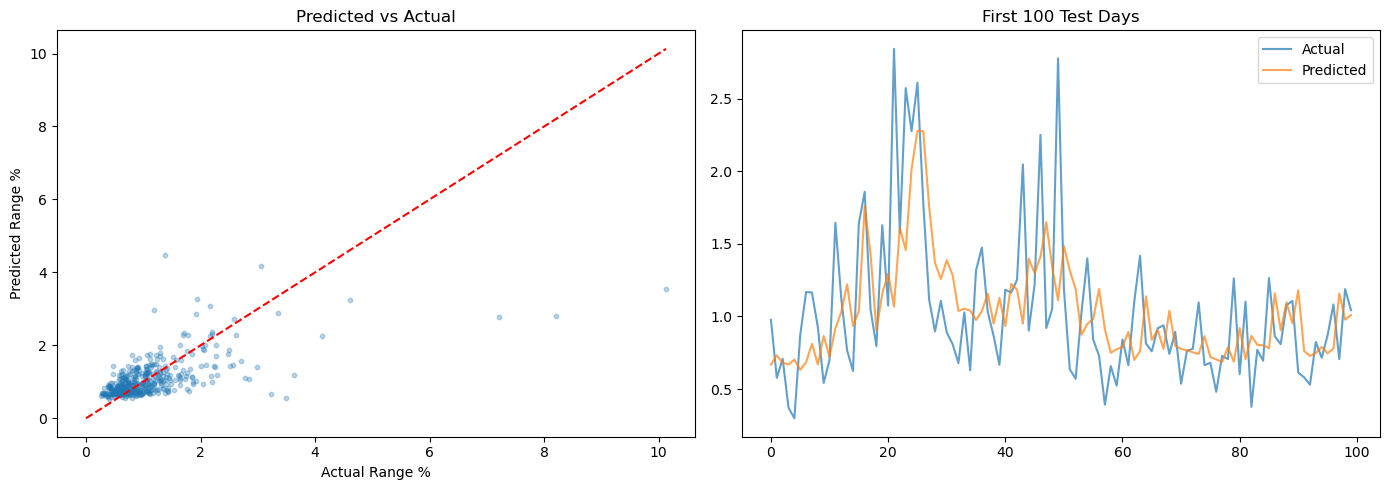

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, predictions, alpha=0.3, s=10)
axes[0].plot([0, y_test.max()], [0, y_test.max()], "r--")
axes[0].set_xlabel("Actual Range %")
axes[0].set_ylabel("Predicted Range %")
axes[0].set_title("Predicted vs Actual")

axes[1].plot(y_test[:100], label="Actual", alpha=0.7)
axes[1].plot(predictions[:100], label="Predicted", alpha=0.7)
axes[1].set_title("First 100 Test Days")
axes[1].legend()
plt.tight_layout()
plt.show()

In [13]:
# Make sure we're comparing against the right column
print("Columns:", list(test_df.columns))
print(f"Column at index 3: {test_df.columns[3]}")
print(f"Sample values - Target: {y_test[:5]}")
print(f"Sample values - Naive:  {naive_pred[:5]}")

Columns: ['TARGET_NEXT_DAY_RANGE_PCT', 'DAILY_RETURN_PCT', 'OVERNIGHT_GAP_PCT', 'INTRADAY_RANGE_PCT', 'CLOSE_LOCATION_IN_RANGE', 'HIGH_VS_PREV_CLOSE_PCT', 'LOW_VS_PREV_CLOSE_PCT', 'AVG_RANGE_5D', 'AVG_RANGE_10D', 'AVG_RANGE_20D', 'STDDEV_RETURN_5D', 'STDDEV_RETURN_20D', 'VOLUME_RATIO_20D', 'RETURN_5D', 'RETURN_20D', 'DOWN_DAYS_LAST_3', 'DAY_OF_WEEK', 'MONTH_OF_YEAR']
Column at index 3: INTRADAY_RANGE_PCT
Sample values - Target: [0.9763028  0.57665107 0.70856772 0.37100202 0.29865784]
Sample values - Naive:  [0.61612939 0.9763028  0.57665107 0.70856772 0.37100202]


In [15]:
from sagemaker.tuner import HyperparameterTuner, IntegerParameter, ContinuousParameter

container = sagemaker.image_uris.retrieve("xgboost", region, version="1.7-1")

tuning_estimator = Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    output_path=f"s3://{bucket}/{prefix}/models/",
    sagemaker_session=session,
    hyperparameters={
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "early_stopping_rounds": 20,
    }
)

hyperparameter_ranges = {
    "max_depth": IntegerParameter(2, 10),
    "eta": ContinuousParameter(0.01, 0.3),
    "subsample": ContinuousParameter(0.5, 1.0),
    "colsample_bytree": ContinuousParameter(0.3, 1.0),
    "min_child_weight": IntegerParameter(1, 20),
    "num_round": IntegerParameter(50, 500),
    "gamma": ContinuousParameter(0, 5),
    "alpha": ContinuousParameter(0, 10),
    "lambda": ContinuousParameter(0, 10),
}

tuner = HyperparameterTuner(
    estimator=tuning_estimator,
    objective_metric_name="validation:rmse",
    objective_type="Minimize",
    hyperparameter_ranges=hyperparameter_ranges,
    max_jobs=20,
    max_parallel_jobs=4,
    strategy="Bayesian"
)

tuner.fit({"train": train_input, "validation": val_input})

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating hyperparameter tuning job with name: sagemaker-xgboost-260311-1707


..........................................................................!


In [16]:
# Check best training job
best_job = tuner.best_training_job()
print(f"Best training job: {best_job}")

# Get all results as a dataframe
tuning_results = sagemaker.HyperparameterTuningJobAnalytics(
    tuner.latest_tuning_job.name
).dataframe()

print(f"\nTop 5 jobs by RMSE:")
print(tuning_results.sort_values("FinalObjectiveValue").head()[
    ["TrainingJobName", "FinalObjectiveValue", "TrainingJobStatus"]
])

Best training job: sagemaker-xgboost-260311-1707-008-912a641b

Top 5 jobs by RMSE:
                               TrainingJobName  FinalObjectiveValue  \
12  sagemaker-xgboost-260311-1707-008-912a641b              0.34943   
17  sagemaker-xgboost-260311-1707-003-bc706487              0.34986   
15  sagemaker-xgboost-260311-1707-005-cb9e34d1              0.35038   
4   sagemaker-xgboost-260311-1707-016-f6086b3f              0.35106   
16  sagemaker-xgboost-260311-1707-004-7fc51904              0.35268   

   TrainingJobStatus  
12         Completed  
17         Completed  
15         Completed  
4          Completed  
16         Completed  


In [17]:
# Attach to the best estimator from tuning
best_estimator = tuner.best_estimator()

best_predictor = best_estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    serializer=sagemaker.serializers.CSVSerializer(),
    deserializer=sagemaker.deserializers.CSVDeserializer()
)

# Predict on test set
tuned_predictions = []
for i in range(0, len(X_test), batch_size):
    batch = X_test[i:i+batch_size]
    csv_batch = "\n".join([",".join(map(str, row)) for row in batch])
    result = best_predictor.predict(csv_batch)
    preds = [float(r[0]) for r in result]
    tuned_predictions.extend(preds)

tuned_predictions = np.array(tuned_predictions)

# Compare
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))
tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_r2 = r2_score(y_test, tuned_predictions)

print(f"===== Tuned Model Results =====")
print(f"  RMSE:  {tuned_rmse:.4f}  (was {rmse:.4f})")
print(f"  MAE:   {tuned_mae:.4f}  (was {mae:.4f})")
print(f"  R²:    {tuned_r2:.4f}  (was {r2:.4f})")
print(f"")
print(f"  Naive Baseline RMSE: {naive_rmse:.4f}")
print(f"  Improvement over naive: {(1 - tuned_rmse/naive_rmse)*100:.1f}%")


2026-03-11 17:11:11 Starting - Found matching resource for reuse
2026-03-11 17:11:11 Downloading - Downloading the training image
2026-03-11 17:11:11 Training - Training image download completed. Training in progress.
2026-03-11 17:11:11 Uploading - Uploading generated training model
2026-03-11 17:11:11 Completed - Resource reused by training job: sagemaker-xgboost-260311-1707-012-35650a6f

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-03-11-17-18-24-037


INFO:sagemaker:Creating endpoint-config with name sagemaker-xgboost-2026-03-11-17-18-24-037
INFO:sagemaker:Creating endpoint with name sagemaker-xgboost-2026-03-11-17-18-24-037


------!===== Tuned Model Results =====
  RMSE:  0.6941  (was 0.6994)
  MAE:   0.3797  (was 0.3872)
  R²:    0.3967  (was 0.3875)

  Naive Baseline RMSE: 0.7023
  Improvement over naive: 1.2%


In [28]:
best_predictor.delete_endpoint()
print("Endpoint deleted")

INFO:sagemaker:Deleting endpoint configuration with name: sagemaker-xgboost-2026-03-11-17-18-24-037


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 best_predictor.delete_endpoint()                                                             │
│   2 print("Endpoint deleted")                                                                    │
│   3                                                                                              │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/base_predictor.py:527 in delete_endpoint       │
│                                                                                                  │
│   524 │   │   │   │   be deleted. If False, only endpoint will be deleted.                       │
│   525 │   │   """                                                                                │
│   526 │   │   if delete_endpoint_config:                                                         │
│ ❱ 527 │   │   │   self._delete_endpoint_config()                                                 │
│   528 │   │                                                                                      │
│   529 │   │   self.sagemaker_session.delete_endpoint(self.endpoint_name)                         │
│   530                                                                                            │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/base_predictor.py:512 in                       │
│ _delete_endpoint_config                                                                          │
│                                                                                                  │
│   509 │   def _delete_endpoint_config(self):                                                     │
│   510 │   │   """Delete the Amazon SageMaker endpoint configuration"""                           │
│   511 │   │   current_endpoint_config_name = self._get_endpoint_config_name()                    │
│ ❱ 512 │   │   self.sagemaker_session.delete_endpoint_config(current_endpoint_config_name)        │
│   513 │                                                                                          │
│   514 │   def delete_endpoint(self, delete_endpoint_config=True):                                │
│   515 │   │   """Delete the Amazon SageMaker endpoint backing this predictor.                    │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/session.py:5007 in delete_endpoint_config      │
│                                                                                                  │
│   5004 │   │   │   │   delete.                                                                   │
│   5005 │   │   """                                                                               │
│   5006 │   │   logger.info("Deleting endpoint configuration with name: %s", endpoint_config_nam  │
│ ❱ 5007 │   │   self.sagemaker_client.delete_endpoint_config(EndpointConfigName=endpoint_config_  │
│   5008 │                                                                                         │
│   5009 │   def create_inference_component(                                                       │
│   5010 │   │   self,                                                                             │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/botocore/client.py:569 in _api_call                      │
│                                                            

In [21]:
from sagemaker.model import Model
from sagemaker.serverless import ServerlessInferenceConfig
from sagemaker.predictor import Predictor

# Clean up the failed attempt
try:
    session.delete_model(model_name="spy-volatility-forecast")
    session.delete_endpoint(endpoint_name="spy-volatility-endpoint")
    session.delete_endpoint_config(endpoint_config_name="spy-volatility-endpoint")
except:
    pass
best_model = Model(
    image_uri=container,
    model_data=tuner.best_estimator().model_data,
    role=role,
    sagemaker_session=session,
    name="spy-volatility-forecast"
)

serverless_config = ServerlessInferenceConfig(
    memory_size_in_mb=2048,
    max_concurrency=5,
)

best_model.deploy(
    serverless_inference_config=serverless_config,
    endpoint_name="spy-volatility-endpoint"
)

# Create predictor manually
endpoint_predictor = Predictor(
    endpoint_name="spy-volatility-endpoint",
    sagemaker_session=session,
    serializer=sagemaker.serializers.CSVSerializer(),
    deserializer=sagemaker.deserializers.CSVDeserializer()
)

print(f"Serverless endpoint deployed: {endpoint_predictor.endpoint_name}")

INFO:sagemaker:Deleting model with name: spy-volatility-forecast
INFO:sagemaker:Deleting endpoint with name: spy-volatility-endpoint
INFO:sagemaker:Deleting endpoint configuration with name: spy-volatility-endpoint



2026-03-11 17:11:11 Starting - Found matching resource for reuse
2026-03-11 17:11:11 Downloading - Downloading the training image
2026-03-11 17:11:11 Training - Training image download completed. Training in progress.
2026-03-11 17:11:11 Uploading - Uploading generated training model
2026-03-11 17:11:11 Completed - Resource reused by training job: sagemaker-xgboost-260311-1707-012-35650a6f

INFO:sagemaker:Creating model with name: spy-volatility-forecast


INFO:sagemaker:Creating endpoint-config with name spy-volatility-endpoint
INFO:sagemaker:Creating endpoint with name spy-volatility-endpoint


--------!Serverless endpoint deployed: spy-volatility-endpoint


In [22]:
# Grab a single row of features from the test set
sample_features = X_test[0]
csv_payload = ",".join(map(str, sample_features))

result = endpoint_predictor.predict(csv_payload)
actual = y_test[0]

print(f"Input features: {sample_features}")
print(f"Predicted next-day range: {float(result[0][0]):.3f}%")
print(f"Actual next-day range:    {actual:.3f}%")

Input features: [ 0.20579913  0.2590864   0.61612939  0.83928571  0.3050237  -0.31237367
  0.73396344  0.7211214   0.82042878  0.33493002  0.44405285  0.82264856
  0.47905074  3.40747483  1.          1.          7.        ]
Predicted next-day range: 0.695%
Actual next-day range:    0.976%


In [26]:
from sagemaker.model_monitor import DefaultModelMonitor

monitor = DefaultModelMonitor(
    role=role,
    instance_count=1,
    instance_type="ml.m5.large",    # smaller instance
    volume_size_in_gb=20,
    max_runtime_in_seconds=3600,
)

monitor.suggest_baseline(
    baseline_dataset=f"s3://{bucket}/{prefix}/data/train/train_xgb.csv",
    dataset_format=sagemaker.model_monitor.DatasetFormat.csv(header=False),
    output_s3_uri=f"s3://{bucket}/{prefix}/monitoring/baseline",
    wait=True
)

print("Baseline created successfully")
print(f"Statistics: {monitor.baseline_statistics().s3_uri}")
print(f"Constraints: {monitor.suggested_constraints().s3_uri}")

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating processing-job with name baseline-suggestion-job-2026-03-11-17-50-27-235


.......................2026-03-11 17:54:15.518532: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-11 17:54:15.518577: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-03-11 17:54:17.053051: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-03-11 17:54:17.053087: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-03-11 17:54:17.053134: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (ip-10-0-248-239.us-east-2.compute.internal): /proc/driver/nvidia/version does not exist
2026-03-11 

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:19                                                                                   │
│                                                                                                  │
│   16 )                                                                                           │
│   17                                                                                             │
│   18 print("Baseline created successfully")                                                      │
│ ❱ 19 print(f"Statistics: {monitor.baseline_statistics().s3_uri}")                                │
│   20 print(f"Constraints: {monitor.suggested_constraints().s3_uri}")                             │
│   21                                                                                             │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
AttributeError: 'Statistics' object has no attribute 's3_uri'

In [27]:
stats = monitor.baseline_statistics()
constraints = monitor.suggested_constraints()

print(f"Statistics: {stats.file_s3_uri}")
print(f"Constraints: {constraints.file_s3_uri}")

Statistics: s3://spy-volatility-forecast-yusuf/volatility-forecast/monitoring/baseline/statistics.json
Constraints: s3://spy-volatility-forecast-yusuf/volatility-forecast/monitoring/baseline/constraints.json


In [29]:
# DON'T run this until you've seen the results above
predictor.delete_endpoint()
print("Endpoint deleted")


INFO:sagemaker:Deleting endpoint configuration with name: sagemaker-xgboost-2026-03-09-18-02-21-910
INFO:sagemaker:Deleting endpoint with name: sagemaker-xgboost-2026-03-09-18-02-21-910


Endpoint deleted


In [30]:
sm_client = boto3.client("sagemaker")

# Check all active endpoints
endpoints = sm_client.list_endpoints(StatusEquals="InService")
for ep in endpoints["Endpoints"]:
    print(f"Active endpoint: {ep['EndpointName']}")
    
    # Check if it's serverless (free when idle) or real-time (charges continuously)
    config = sm_client.describe_endpoint_config(
        EndpointConfigName=ep["EndpointName"]
    )
    if "ProductionVariants" in config:
        for variant in config["ProductionVariants"]:
            if "ServerlessConfig" in variant:
                print("  → Serverless (only charges per request, free when idle)")
            else:
                instance_type = variant.get("InstanceType", "unknown")
                print(f"  → Real-time instance: {instance_type} (CHARGING YOU RIGHT NOW)")

Active endpoint: spy-volatility-endpoint
  → Serverless (only charges per request, free when idle)
